# Recourse

In [120]:
#%%
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [121]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging
from itertools import combinations

from monoculture.analysis.setup import ACS_TASKS, TABLESHIFT_TASKS, baselines
from monoculture.analysis.utils import (
    key_to_model,
    get_size_and_it,
    load_model_outputs_same_prompt,
    get_metric,
    load_task_data,
)
from monoculture.analysis.plotting import (
    plot_model_agreement_multiple_tasks,
    plot_recourse_lineplot,
    plot_recourse_barplot,
)
from monoculture.baseline.utils import load_baselines

In [122]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

TASKS = ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR / "overview_results_by_prompt_style.csv"
FIGURES_ROOT_DIR = RESULTS_ROOT_DIR / "figures/same-prompt"
FIGURES_PAPER_DIR = RESULTS_ROOT_DIR / "figures/paper/same-prompt/"


data = None

tasks ('ACSIncome', 'ACSEmployment', 'ACSMobility', 'ACSTravelTime', 'ACSPublicCoverage', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure')


## Load predictions

In [123]:
num_shots = 0
threshold_fitted = 1

df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df_same_prompt = df[
    (df["num_shots"] == num_shots)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == threshold_fitted)
]
df_same_prompt.head()

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
1,ACSIncome,meta-llama--Meta-Llama-3.2-1B-Instruct,1,1,0.776744,0.680409,3019759728,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
2,ACSIncome,allenai--OLMo-2-1124-7B-Instruct,1,1,0.904552,0.727768,3118177042,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-allenai--O...,results/folktexts/0-bullet-is/model-allenai--O...
4,ACSIncome,google--gemma-2-27b,0,1,0.438475,0.510381,3621160589,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
6,ACSIncome,google--gemma-2-27b-it,1,1,0.867235,0.659718,1712994131,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
9,ACSIncome,meta-llama--Meta-Llama-3-70B,0,1,0.532134,0.763641,4121241683,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...


In [124]:
print(df_same_prompt.shape)
try:
    assert set(TASKS).issubset(
        set(df_same_prompt["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df_same_prompt['task'].unique())} "
except AssertionError:
    logging.warning("Reduced TASKS to available tasks.")
    TASKS = list(df_same_prompt["task"].unique())
TASKS

(273, 14)


['ACSIncome',
 'ACSEmployment',
 'ACSTravelTime',
 'ACSPublicCoverage',
 'BRFSS_Diabetes',
 'BRFSS_Blood_Pressure']

In [125]:
risk_scores = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=True
)
predictions_all = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=False
)

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "fnr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for metric in metrics:
    df_same_prompt[metric] = (
        df_same_prompt["eval_results_path"]
        .apply(partial(get_metric, metric=metric))
        .copy()
    )

evals_per_task_all = {}  # [task][metric][model]
for task in df_same_prompt["task"].unique():
    df_task = df_same_prompt[df_same_prompt["task"] == task]
    evals_per_task_all[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }

/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_17068/1453958818.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_17068/1453958818.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_17068/1453958818.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

## Restrict analysis to models based on performance or true labels?

In [126]:
restrict_to_better_const = True
restrict_to_positive_label = True
restrict_to_negative_label = False
assert not (
    restrict_to_positive_label & restrict_to_negative_label
), "Choose one or none."

restrict_to_model_family = False  #'Llama'  # name of family
restrict_to_base_models = False
restrict_to_it_models = False
assert not (restrict_to_base_models and restrict_to_it_models), "Choose one or none."

restrict_to_top_eps = False #True
restrict_to_topk = False
topk = 10
eps = 0.05

predictions = predictions_all.copy()

if any(
    [restrict_to_better_const, restrict_to_positive_label, restrict_to_negative_label]
):
    if not data:
        logging.warning("Load task data")
        data = load_task_data(TASKS, Path("./data"))

    for task in TASKS:
        df_task = df_same_prompt[df_same_prompt["task"] == task]
        y_true = data[task][1]

        if restrict_to_better_const:
            const_acc = max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
            models_better_const = sorted(
                df_task["model"][df_task["accuracy"] > const_acc].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models_better_const)

        if restrict_to_negative_label or restrict_to_positive_label:
            filter_idx = y_true[y_true == int(restrict_to_positive_label)].index
            predictions[task] = predictions[task].loc[filter_idx]
        print(task, predictions[task].shape)

if restrict_to_topk or restrict_to_top_eps:
    assert not (restrict_to_top_eps and restrict_to_topk)
    for task in TASKS:
        df_task_sorted_by_acc = df_same_prompt[
            df_same_prompt["task"] == task
        ].sort_values(by="accuracy", ascending=False)
        if restrict_to_topk:
            models = sorted(
                df_task_sorted_by_acc.iloc[:topk]["model"].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models)
        if restrict_to_top_eps:
            top_acc = df_task_sorted_by_acc.iloc[0]["accuracy"].item()
            models = sorted(
                df_task_sorted_by_acc[
                    df_task_sorted_by_acc["accuracy"] > top_acc - eps
                ]["model"].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models)
        print(task, predictions[task].shape)

if restrict_to_model_family:
    print(f"Restrict to model family {restrict_to_model_family}")
    for task in TASKS:
        models_filtered = list(
            df_same_prompt[
                df_same_prompt.apply(
                    lambda row: (row.task == task)
                    & (row.model in predictions[task].columns)
                    & (restrict_to_model_family in row.model),
                    axis=1,
                )
            ]["model"].unique()
        )
        print(len(models_filtered))
        predictions[task] = predictions[task].filter(items=models_filtered)
        print(task, predictions[task].shape)

if any([restrict_to_base_models, restrict_to_it_models]):
    for task in TASKS:
        models_filtered = list(
            df_same_prompt[
                df_same_prompt.apply(
                    lambda row: (row.task == task)
                    & (row.model in predictions[task].columns)
                    & (row.is_inst == int(restrict_to_it_models)),
                    axis=1,
                )
            ]["model"].unique()
        )
        predictions[task] = predictions[task].filter(items=models_filtered)
        print(task, predictions[task].shape)

evals_per_task = {
    task: {
        metric: {
            model: evals_per_task_all[task][metric][model]
            for model in predictions[task].columns
        }
        for metric in evals_per_task_all[task].keys()
    }
    for task in evals_per_task_all.keys()
}

ACSIncome (61233, 40)
ACSEmployment (146740, 42)
ACSTravelTime (64285, 19)
ACSPublicCoverage (33971, 12)
BRFSS_Diabetes (19119, 0)
BRFSS_Blood_Pressure (44586, 32)


## Systemic Failure (No Recourse) as a function of the model set size

Ideally, we would want to measure no recourse for all possible combinations of models, all subsets of the set of models (powerset!). However, this quickly becomes too expennsive as we get $2^M$ possible subsets for $M$ models. 

In [127]:
2**40

1099511627776

$n\choose k$ many subsets of size $k$

In [128]:
len(list(combinations(np.arange(40), r=3)))  # r=2: n(n-1) many samples

9880

make use of the fact that the number of individuals without recourse can only get smaller when adding another model
- sort models, givem them indices
- for any subset, check if the set itself or the prefix up to -1 was already computed
- build lookup table

In [129]:
N, M = predictions["ACSIncome"].shape
print(f"{M} models")
models = sorted(predictions["ACSIncome"].columns.tolist(), key=get_size_and_it)
indexed_models = {i: model for i, model in enumerate(models)}

subsets_all_reject = {}

predictions_array = predictions["ACSIncome"].to_numpy()

def indices_all_reject(predictions_array, subset_indices):
    return np.where(np.bitwise_or.reduce(predictions_array[:, subset_indices], axis=1) == 0)[0]
    # return set(np.where(np.sum(predictions_array[:, subset_indices] == 0, axis=1))[0])

def update_all_reject_set(predictions_array, subset_indices):
    # print('subset_indices', subset_indices)
    assert len(subset_indices) > 0
    if len(subset_indices) == 1:
        # no previous
        return indices_all_reject(predictions_array, subset_indices)
    else:
        idx_prefix_all_reject = subsets_all_reject[len(subset_indices) - 1].get(
            subset_indices[:-1]
        )
        if idx_prefix_all_reject != idx_prefix_all_reject:  # None
            # prune: nobody rejected by all prev models
            return set()
        else:
            # intersection of sets, if not already empty
            return idx_prefix_all_reject.intersection(
                subsets_all_reject[1].get(subset_indices[-1:], set())
            )

def update_all_reject(predictions_array, subset_indices):
    assert len(subset_indices) > 0
    if len(subset_indices) == 1:
        # no previous
        return indices_all_reject(predictions_array, subset_indices)
    else:
        # find previously rejected indices
        idx_prev_all_reject = subsets_all_reject[len(subset_indices) - 1].get(
            subset_indices[:-1]
        )
        # only check remaining predictions
        still_rejected = predictions_array[idx_prev_all_reject, subset_indices[-1]] == 0
        return idx_prev_all_reject[still_rejected]



40 models


In [130]:
# toy example
# toy_pred = np.random.binomial(n=1, p=0.05, size=[5, 20])
# Ntoy, Mtoy = toy_pred.shape
# display(toy_pred)
# display(toy_pred.sum(axis=1))

# subsets_all_reject = {}
# for k in range(1,Mtoy+1):
#     # print(k)
#     subsets_all_reject[k] = {}
#     if k == 1:
#         subsets = np.arange(Mtoy).reshape(-1,1)
#     else:
#         # print( subsets_all_reject[k-1].keys())
#         subsets = [(*pre, n) for pre in subsets_all_reject[k-1].keys() for n in range(pre[-1]+1, Mtoy)]
#         # print(subsets)
#     for sub in subsets:
#         idx_rejected_by_all = update_all_reject_incremental(toy_pred, sub)
#         # print('idx_rejected_by_all:', idx_rejected_by_all, len(idx_rejected_by_all))
#         if len(idx_rejected_by_all) > 0:
#             subsets_all_reject[k][tuple(sub)] = idx_rejected_by_all
#     # print(subsets_all_reject.keys())

# subsets_all_reject[Mtoy]

In [131]:
# only run when filtered models 
if False:
    subsets_all_reject = {}
    for k in range(1, M) : #M if M<30 else 30):
        print(k, end=' ')
        subsets_all_reject[k] = {}
        if k == 1:
            subsets = np.arange(M).reshape(-1, 1)
        else:
            # print( subsets_all_reject[k-1].keys())
            subsets = [
                (*pre, n)
                for pre in subsets_all_reject[k - 1].keys()
                for n in range(pre[-1] + 1, M)
            ]
        print(f"{len(subsets)} subsets", end='\n')
            # print(subsets)
        for sub in subsets:
            idx_rejected_by_all = update_all_reject(predictions_array, sub)
            # print('idx_rejected_by_all:', idx_rejected_by_all, len(idx_rejected_by_all))
            if len(idx_rejected_by_all) > 0:
                subsets_all_reject[k][tuple(sub)] = idx_rejected_by_all
        # print(subsets_all_reject.keys())

## Systemic Failure (No Recourse) as a function of the Rashomon Set Size

In [132]:
from monoculture.analysis.metrics import get_fraction_no_recourse, poisson_binom_agreement

In [134]:
predictions_eps = {}
epsilon_per_task = {}

for task in TASKS:
    predictions_eps[task] = {}
    df_task_sorted_by_acc = df_same_prompt[df_same_prompt["task"] == task].sort_values(
        by="accuracy", ascending=False
    )
    top_acc = df_task_sorted_by_acc.iloc[0]["accuracy"].item()
    # y_true = data[task][1]
    # const_acc = max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
    # print(f"{task} top: {top_acc:.4f} const: {const_acc:.4f} diff: {top_acc - const_acc}")
    max_eps = 0.05
    
    # epsilon = np.arange(0, top_acc - const_acc+0.005, 0.005)
    epsilon = np.arange(0,max_eps+0.005, 0.005)
    epsilon_per_task[task] = epsilon
    no_recourse_observed = []
    no_recourse_at_random = []
    num_models = []
    for eps in epsilon:
        models = sorted(
            df_task_sorted_by_acc[df_task_sorted_by_acc["accuracy"] >= top_acc - eps][
                "model"
            ].to_list(),
            key=get_size_and_it,
        )

        tp_rates = [1. - evals_per_task_all[task]['fnr'][model] for model in models]

        if len(models) > 0 and predictions[task].shape[1] > 0:
            no_recourse_observed.append(
                get_fraction_no_recourse(
                    predictions[task].filter(items=models).to_numpy()
                )
            )
            no_recourse_at_random.append(poisson_binom_agreement(baseline_rate=tp_rates, k=0))
            num_models.append(len(models))
    if predictions[task].shape[1] > 0:
        predictions_eps[task] = {
            "eps": epsilon,
            "num_models": num_models,
            "observed": no_recourse_observed,
            "random_error": no_recourse_at_random,
        }
    print(task, predictions_eps[task])

ACSIncome {'eps': array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
       0.045, 0.05 ]), 'num_models': [1, 1, 3, 6, 6, 11, 14, 16, 20, 21, 21], 'observed': [0.23471004197083273, 0.23471004197083273, 0.18682736432969152, 0.1621347965966064, 0.1621347965966064, 0.11258635049728088, 0.10169353126582072, 0.09447520128035536, 0.07842176604118695, 0.07731125373573074, 0.07731125373573074], 'random_error': [0.23471004197083278, 0.23471004197083278, 0.013243304583424797, 0.00013138317510660833, 0.00013138317510660833, 5.436809355308138e-08, 4.601126506894644e-10, 1.8876712378709886e-11, 2.412356117156881e-14, 5.097492495858912e-15, 5.097492495858912e-15]}
ACSEmployment {'eps': array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
       0.045, 0.05 ]), 'num_models': [1, 2, 3, 4, 4, 6, 6, 6, 6, 7, 7], 'observed': [0.151008586615783, 0.1351233474172005, 0.12677524873926674, 0.09062968515742129, 0.09062968515742129, 0.07494207441733679, 0.07494207441733679, 0

no-recourse-0-shot_tresh_fitted_better_const_pos_instances.png


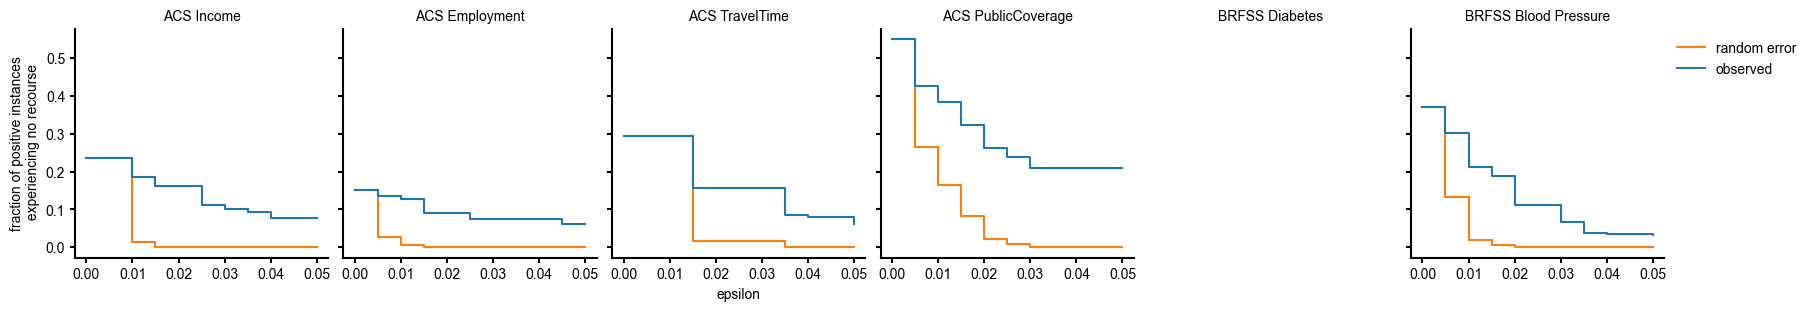

In [139]:
tasks_to_plot = TASKS  # ['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure']

fig, axs = plt.subplots(
    1,
    len(tasks_to_plot),
    figsize=(3 * len(tasks_to_plot), 3),
    constrained_layout=True,
    sharey="row",
)

for t, task in enumerate(tasks_to_plot):
    if len(predictions_eps[task]) > 0:
        axs[t].step(
            predictions_eps[task]["eps"],
            predictions_eps[task]["random_error"],
            where="post",
            color="C1",
            label="random error",
        )

        axs[t].step(
            predictions_eps[task]["eps"],
            predictions_eps[task]["observed"],
            where="post",
            color="C0",
            label="observed",
        )

        # fix x-lim to include limits
        # Add min and max if not already in the tick list
        xvals = predictions_eps[task]["eps"]
    else:
        axs[t].set_axis_off()
    axs[t].set_title(task.replace("ACS", "ACS ").replace("_", " "))
# axs[0].legend()
axs[0].set_ylabel("fraction of positive instances\n experiencing no recourse")
axs[len(tasks_to_plot) // 2 - 1].set_xlabel("epsilon")

# legend
handles, labels = axs[0].get_legend_handles_labels()
plt.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.0, 1.0))

file_name = "".join(
    [
        f"no-recourse-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_better_const" if restrict_to_better_const else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
        ".png",
    ]
)
plt.savefig(FIGURES_ROOT_DIR / file_name)
plt.savefig(FIGURES_PAPER_DIR / file_name)
print(file_name)

plt.show()

In [118]:
m = predictions_eps[task]['num_models'][np.where(predictions_eps[task]['eps']==0.01)[0][0]]
df_same_prompt[df_same_prompt['task']=='ACSIncome'].sort_values(by='accuracy', ascending=False).iloc[:m]

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,...,prompt_feature_order,eval_results_path,predictions_path,n_samples,fpr,fnr,ppr,num_pred_negatives,num_pred_positives,balanced_accuracy
89,ACSIncome,meta-llama--Meta-Llama-3.3-70B-Instruct,1,1,0.999292,0.788483,364117336,0,bullet,is,...,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...,166450,0.198019,0.234710,0.406705,98754,67696,0.783635
64,ACSIncome,Qwen--Qwen2.5-72B,0,1,0.320242,0.780667,3802773871,0,bullet,is,...,default,results/folktexts/0-bullet-is/model-Qwen--Qwen...,results/folktexts/0-bullet-is/model-Qwen--Qwen...,166450,0.214747,0.227214,0.420036,96535,69915,0.779020
87,ACSIncome,mistralai--Mistral-Small-24B-Instruct-2501,1,1,0.867116,0.780366,3235594015,0,bullet,is,...,default,results/folktexts/0-bullet-is/model-mistralai-...,results/folktexts/0-bullet-is/model-mistralai-...,166450,0.202933,0.248330,0.404800,99071,67379,0.774368


In [145]:
a= np.array([1,1,0,0.3, np.nan])
a

array([1. , 1. , 0. , 0.3, nan])

In [146]:
np.clip(a, 0., 1.)

array([1. , 1. , 0. , 0.3, nan])